# Prioritized replay: sample large TD errors more often

Prioritized replay samples item $i$ with
$$P(i)=\frac{p_i^\alpha}{\sum_kp_k^\alpha},\qquad w_i=\left(NP(i)\right)^{-\beta}.$$
Here $p_i=|\delta_i|+\varepsilon$ is priority, $\alpha$ controls prioritization, $N$ is buffer size, and $\beta$ controls importance correction. This standalone study implements sampling and priority updates directly.

## 1. Build a small replay buffer

Transitions and priorities share indices. New items receive the largest current priority so they are sampled promptly.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

CAPACITY = 100
ALPHA = 0.6
BETA = 0.4
PRIORITY_EPSILON = 1e-6
rng = np.random.default_rng(7)
transitions, priorities = [], np.zeros(CAPACITY)
next_index = 0

def add(transition):
    global next_index
    priority = priorities[:len(transitions)].max(initial=1.0)
    if len(transitions) < CAPACITY:
        transitions.append(transition)
    else:
        transitions[next_index] = transition
    priorities[next_index] = priority
    next_index = (next_index + 1) % CAPACITY

def sample(batch_size):
    active = priorities[:len(transitions)]
    probabilities = active**ALPHA / np.sum(active**ALPHA)
    indices = rng.choice(len(transitions), batch_size, p=probabilities)
    weights = (len(transitions) * probabilities[indices])**(-BETA)
    return indices, weights / weights.max(), probabilities

## 2. Update priorities from TD errors

After optimization, absolute TD errors become the new priorities.

In [2]:
for index in range(10):
    add((index, index % 2, float(index)))
td_errors = np.linspace(0.1, 2.0, len(transitions))
priorities[:len(transitions)] = np.abs(td_errors) + PRIORITY_EPSILON
indices, weights, probabilities = sample(5)
print("Sampled indices:", indices)
print("Importance weights:", weights)

Sampled indices: [7 9 8 3 4]
Importance weights: [0.83203466 0.78600486 0.80733247 1.         0.94108756]


## 3. Inspect the sampling distribution

The bars show how $lpha$ turns TD-error magnitude into replay probability.

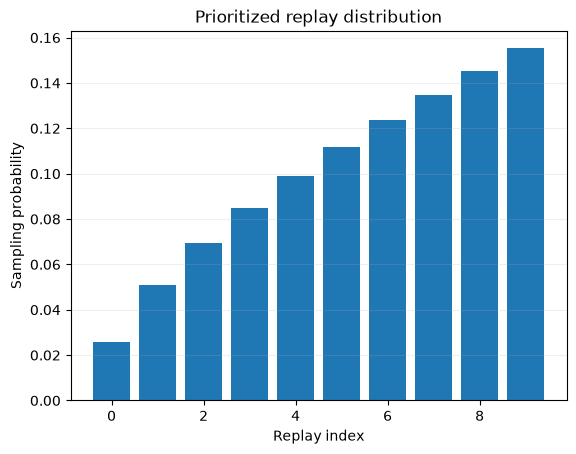

In [3]:
plt.bar(np.arange(len(probabilities)), probabilities)
plt.xlabel("Replay index")
plt.ylabel("Sampling probability")
plt.title("Prioritized replay distribution")
plt.grid(axis="y", alpha=0.2)
plt.show()